# But de ce code: tracer des cartes de manière rapide sous Python, en utilisant netCDF, matplotlib et cartopy

##### Written March 12, 2026
##### Tutorial exemple pour Céleste et Marion

Ce code montre:
1) Comment importer des modules Python (ou les installer);

2) Comment lire des données CMIP6 (généralement sous la forme de fichiers netcdf) en utilisant le module netCDF4 de Python; 

3) Comment sélectionner des données sur une zone d'étude, par exemple l'océan Indien Sud;

4) Comment tracer ces données sur une carte, avec différents niveaux de complexité.
(voir les codes tuto_subplots et tuto_subplots_with_gridspec pour des exemples de plots un peu plus complexes).

### Etape 1: Importer les modules

Beaucoup de ces modules sont téléchargés par défaut lorsqu'on installe Python/Anaconda sur un ordinateur.
**Si certains de ces modules ne sont pas installés par défaut**, il faut les installer à la main, en utilisant l'une des lignes de code ci-dessous:
    
pip install module
    
(par exemple pip install cartopy)

Ou avec conda:
conda install module


In [1]:
import numpy as np

# Modules pour lire les données netCDF
import netCDF4
from netCDF4 import Dataset


# Modules pour tracer des graphiques en Python

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# CARTOPY = tracer des cartes
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# cmocean = colorbars adaptées pour l'océano
import cmocean


/home/analivaev/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Option: on peut aussi inclure les modules à charger dans un fichier à part, et exécuter ce fichier en début de script.
Vérifier dans ce cas que tous les modules contenus dans le fichier sont déjà installés (le code renvoie un message d'erreur sinon).
Dans mon cas j'ai créé un fichier import_modules.py que je charge systématiquement en début de tous mes scripts.
Exemple ci-dessous:

In [36]:
# Version alternative
rep_modules='/home/analivaev/Documents/THESE/Scripts/Zooplankton_Celeste/'
file_modules="import_modules.py"
with open(rep_modules+file_modules) as file:
    exec(file.read())


### Etape 2: Lire les données:

On va utiliser un module spécifique dans Python pour lire les données: le module netCDF4.

Les données CMIP6 sont stockées dans des fichiers "netCDF" ou .nc (par exemple, fichierxxx.nc).
On utilise la fonction Dataset du module netCDF4 de Python pour lire les données contenues dans un fichier, et notamment toutes les variables contenues.

Tu peux trouver la documentation complète ici: https://unidata.github.io/netcdf4-python/ 

NB: on peut utiliser d'autres modules pour lire des fichiers netCDF, par exemple le module xarray (je trouve que netcdf est plus simple à expliquer).

Dans ce code, je prends l'exemple d'un fichier de chlorophylle IPSL, à remplacer par un fichier de zooplancton pour Céleste.

In [2]:
# Définir le répertoire où sont stockées les données
rep_model='/home/analivaev/Documents/THESE/Data/CMIP6/historical/CHL/New_version/'

# Définir le nom du fichier
file_model='monmean_SO_chl_Omon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_199801-201412.nc'

# La ligne suivante lit le fichier et stocke les données en un objet un 'netCDF4' Dataset

data_model=Dataset(rep_model+file_model,'r',format='NETCDF4')
print(type(data_model)) # affiche la classe de données (array, dataframe, float, ...)

print(data_model.variables) # affiche toutes les variables contenues dans l'objet data_model

<class 'netCDF4._netCDF4.Dataset'>
{'time': <class 'netCDF4._netCDF4.Variable'>
float64 time(time)
    standard_name: time
    long_name: Time axis
    units: days since 1850-01-01 00:00:00
    calendar: standard
    axis: T
unlimited dimensions: time
current shape = (12,)
filling off, 'lon': <class 'netCDF4._netCDF4.Variable'>
float64 lon(lon)
    standard_name: longitude
    long_name: longitude
    units: degrees_east
    axis: X
unlimited dimensions: 
current shape = (360,)
filling off, 'lat': <class 'netCDF4._netCDF4.Variable'>
float64 lat(lat)
    standard_name: latitude
    long_name: latitude
    units: degrees_north
    axis: Y
unlimited dimensions: 
current shape = (60,)
filling off, 'area': <class 'netCDF4._netCDF4.Variable'>
float32 area(lat, lon)
    standard_name: cell_area
    units: m2
    _FillValue: nan
    missing_value: nan
unlimited dimensions: 
current shape = (60, 360)
filling off, 'chl': <class 'netCDF4._netCDF4.Variable'>
float32 chl(time, lat, lon)
    standar

Quand on execute data_model.variables, le code affiche toutes les variables contenues dans le fichier, leur 'shape' (c'est à dire leur dimension), leurs unités et une rapide description pour les modèles CMIP.

Par exemple: la variable 'chl' contient cette information : "mass_concentration_of_phytoplankton_expressed_as_chlorophyll_in_sea_water". Elle a pour unités des $kg.m^{-3}$ et pour dimensions (time, lat,lon), soit (12,60,360) dans mon fichier (12 mois x 60 pixels en latitude x 360 pixels en longitude).


In [3]:
print(data_model.variables['chl'])

<class 'netCDF4._netCDF4.Variable'>
float32 chl(time, lat, lon)
    standard_name: mass_concentration_of_phytoplankton_expressed_as_chlorophyll_in_sea_water
    long_name: Mass Concentration of Total Chlorophyll in sea water
    units: kg m-3
    _FillValue: 1e+20
    missing_value: 1e+20
    online_operation: average
    cell_methods: area: mean where sea time: mean
    interval_operation: 2700 s
    interval_write: 1 month
    description: sum of chlorophyll from all phytoplankton group concentrations.  In most models this is equal to chldiat+chlmisc, that is the sum of "Diatom Chlorophyll Mass Concentration" plus "Other Phytoplankton Chlorophyll Mass Concentration"
    history: none
unlimited dimensions: time
current shape = (12, 60, 360)
filling off


In [4]:
# On va donner des noms aux variables pour les appeler plus facilement

lon=data_model.variables['lon']
lat=data_model.variables['lat']

chl=data_model.variables['chl']

print(lon[:])
print(lat[:])

[-180. -179. -178. -177. -176. -175. -174. -173. -172. -171. -170. -169.
 -168. -167. -166. -165. -164. -163. -162. -161. -160. -159. -158. -157.
 -156. -155. -154. -153. -152. -151. -150. -149. -148. -147. -146. -145.
 -144. -143. -142. -141. -140. -139. -138. -137. -136. -135. -134. -133.
 -132. -131. -130. -129. -128. -127. -126. -125. -124. -123. -122. -121.
 -120. -119. -118. -117. -116. -115. -114. -113. -112. -111. -110. -109.
 -108. -107. -106. -105. -104. -103. -102. -101. -100.  -99.  -98.  -97.
  -96.  -95.  -94.  -93.  -92.  -91.  -90.  -89.  -88.  -87.  -86.  -85.
  -84.  -83.  -82.  -81.  -80.  -79.  -78.  -77.  -76.  -75.  -74.  -73.
  -72.  -71.  -70.  -69.  -68.  -67.  -66.  -65.  -64.  -63.  -62.  -61.
  -60.  -59.  -58.  -57.  -56.  -55.  -54.  -53.  -52.  -51.  -50.  -49.
  -48.  -47.  -46.  -45.  -44.  -43.  -42.  -41.  -40.  -39.  -38.  -37.
  -36.  -35.  -34.  -33.  -32.  -31.  -30.  -29.  -28.  -27.  -26.  -25.
  -24.  -23.  -22.  -21.  -20.  -19.  -18.  -17.  -

NB: si on ajoute les "[:]" à la fin (print lon[:] vs print(lon)), le code affiche un array (un vecteur en Python) contenant les valeurs de la longitude: on voit que la longitude va de -180°E à 180°E avec 1° d'espacement entre les valeurs. De même, la latitude va de -89.5°N à -30.5°N avec le même espacement de 1° entre les valeurs.

##### Utiliser des MaskedArrays:
Les sorties de modèles CMIP6 sont la plupart du temps ce qu'on appelle des masked arrays:

In [17]:
# À quoi ressemblent les données de chlorophylle:

print(type(chl[:,:,:]))
print(chl[0,0,0]) # pour extraire une valeur spécifique, on indique un indice sur chaque coordonnée (temps, lat,lon)

<class 'numpy.ma.core.MaskedArray'>
--


Un masked array en Python, c'est un array (un vecteur ou une matrice, ici une matrice 3x3) avec certaines valeurs qui sont "masquées" - par exemple, parce qu'elles correspondent à des points Terre. Ici, tous les points de grille qui sont situés sur le continent Antarctique sont masqués pour la chlorophylle (ne sont pas associés à une valeur de concentration).

C'est le cas pour la valeur de chlorophylle au 1er point de grille longitudinal (-180°E), au 1er point de grille latitudinal (-89.5°N) et à la première coordonnée temps.
Si on lui demande d'afficher cette valeur (print(chl[0,0,0])) le code affiche "--". Le point de grille est masqué car sur un point de terre.

NB: Pour en savoir plus sur les masked arrays:
https://numpy.org/doc/stable/reference/maskedarray.generic.html

Documentation très utile si jamais à un moment on a besoin de traiter des masked arrays, d'extraire le masque, etc.

In [5]:
print(chl[:,:,:]) # ici on écrit [:,:,:] par rapport à lon,lat car la chlorophylle est 3D


[[[-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  ...
  [6.407365435734391e-05 6.398319965228438e-05 6.076235877117142e-05 ...
   5.812574818264693e-05 5.875415445188992e-05 6.094178752391599e-05]
  [5.940291521255858e-05 5.969003905192949e-05 5.7842200476443395e-05
   ... 5.574216993409209e-05 5.620792580884881e-05
   5.7554894738132134e-05]
  [5.652467007166706e-05 5.647217039950192e-05 5.5149885156424716e-05
   ... 5.457037696032785e-05 5.49207761650905e-05 5.574343595071696e-05]]

 [[-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  ...
  [5.4163774620974436e-05 5.365558172343299e-05 5.249948662822135e-05
   ... 5.429804514278658e-05 5.38938729732763e-05 5.387559940572828e-05]
  [5.315386442816816e-05 5.2710667659994215e-05 5.2070219680899754e-05
   ... 5.4079191613709554e-05 5.3682215366279706e-05
   5.336630420060828e-05]
  [5.2980594773544e-05 5.2469531510723755e-05 5.2121617045486346e-05 ...
   5.441092071123421e-05 5.406

##### Aparté: la dimension temps

Reste à voir ce que contient la dimension temps: ici, j'ai traité le fichier en amont pour que la coordonnée temps contienne des moyennes des mêmes mois de l'année (entre les années 1998 et 2014 précisément). Donc, la première coordonnée temps contient la moyenne de tous les mois de Janvier (de 1998 à 2014), la deuxième, celle des mois de Février, etc.
Si besoin, il y a un module pratique sous Python qui s'appelle datetime, pour convertir des dates (par exemple, ici l'unité sur l'axe temps est "days since 1850-01-01 00:00:00", ce qui n'est pas toujours pratique, donc on peut le convertir en jour calendaire).

In [28]:
print(data_model.variables['time'])
print("Pour extraire spécifiquement les unités d'une variable var: commande var.units ",
      data_model.variables['time'].units)

<class 'netCDF4._netCDF4.Variable'>
float64 time(time)
    standard_name: time
    long_name: Time axis
    units: days since 1850-01-01 00:00:00
    calendar: standard
    axis: T
unlimited dimensions: time
current shape = (12,)
filling off
Pour extraire spécifiquement les unités d'une variable var: commande var.units  days since 1850-01-01 00:00:00


### Etape 3 (option): Sélectionner une région de la carte (à passer si on trace les données sur l'ensemble de l'Océan Austral)

Une fonction très utile si les données sont rangées dans l'ordre croissant: np.searchsorted

In [15]:
lon_min,lon_max=20,120 # les limites longitudinales de ma zone d'Etude: océan Indien Sud

ilon_min,ilon_max=np.searchsorted(lon[:],[lon_min,lon_max])
print("Toutes les longitudes: ", lon[:])
print("Indices des longitudes que l'on souhaite :", ilon_min,ilon_max)

print("Valeurs de longitude correspondantes :", lon[ilon_min],lon[ilon_max])

Toutes les longitudes:  [-180. -179. -178. -177. -176. -175. -174. -173. -172. -171. -170. -169.
 -168. -167. -166. -165. -164. -163. -162. -161. -160. -159. -158. -157.
 -156. -155. -154. -153. -152. -151. -150. -149. -148. -147. -146. -145.
 -144. -143. -142. -141. -140. -139. -138. -137. -136. -135. -134. -133.
 -132. -131. -130. -129. -128. -127. -126. -125. -124. -123. -122. -121.
 -120. -119. -118. -117. -116. -115. -114. -113. -112. -111. -110. -109.
 -108. -107. -106. -105. -104. -103. -102. -101. -100.  -99.  -98.  -97.
  -96.  -95.  -94.  -93.  -92.  -91.  -90.  -89.  -88.  -87.  -86.  -85.
  -84.  -83.  -82.  -81.  -80.  -79.  -78.  -77.  -76.  -75.  -74.  -73.
  -72.  -71.  -70.  -69.  -68.  -67.  -66.  -65.  -64.  -63.  -62.  -61.
  -60.  -59.  -58.  -57.  -56.  -55.  -54.  -53.  -52.  -51.  -50.  -49.
  -48.  -47.  -46.  -45.  -44.  -43.  -42.  -41.  -40.  -39.  -38.  -37.
  -36.  -35.  -34.  -33.  -32.  -31.  -30.  -29.  -28.  -27.  -26.  -25.
  -24.  -23.  -22.  -21.  -

Ce que ça veut dire: la fonction donne en sortie les indices correspondant aux valeurs de longitude qu'on lui demande (en l'occurrence 20°E, 120°E), ou elle donne l'indice de la valeur immédiatement au dessus dans la grille. Autre exemple avec la latitude.

In [16]:
lat_subantarctic_min,lat_subantarctic_max=-60,-40
ilat_subantarctic_min,ilat_subantarctic_max=np.searchsorted(lat[:],[lat_subantarctic_min,lat_subantarctic_max])

print("Toutes les latitudes: ", lat[:])
print("Indices des latitudes que l'on souhaite: ", ilat_subantarctic_min, ilat_subantarctic_max)

print("Valeurs de latitude correspondantes : ", lat[ilat_subantarctic_min], lat[ilat_subantarctic_max])

# Là on voit que la fonction sort l'indice de la valeur immédiatement au-dessus, car la latitude
# n'est pas grillée en degrés entiers

Toutes les latitudes:  [-89.5 -88.5 -87.5 -86.5 -85.5 -84.5 -83.5 -82.5 -81.5 -80.5 -79.5 -78.5
 -77.5 -76.5 -75.5 -74.5 -73.5 -72.5 -71.5 -70.5 -69.5 -68.5 -67.5 -66.5
 -65.5 -64.5 -63.5 -62.5 -61.5 -60.5 -59.5 -58.5 -57.5 -56.5 -55.5 -54.5
 -53.5 -52.5 -51.5 -50.5 -49.5 -48.5 -47.5 -46.5 -45.5 -44.5 -43.5 -42.5
 -41.5 -40.5 -39.5 -38.5 -37.5 -36.5 -35.5 -34.5 -33.5 -32.5 -31.5 -30.5]
Indices des latitudes que l'on souhaite:  30 50
Valeurs de latitude correspondantes :  -59.5 -39.5


NB: parfois les latitudes en particulier sont rangées dans l'ordre décroissant (par exemple, elles vont de -30.5°N à -89.5°N), auquel cas il faut prendre l'opposé des données en entrée, par exemple en demandant un np.searchsorted(-lat[:]). (Ce n'est normalement pas le cas dans CMIP mais ça peut arriver)

Comment extraire des valeurs sur une matrice:
matrice[indice_min:indice_max+1]

Les deux points servent à dire : on va du premier indice au deuxième.

Le +1 sert à inclure la valeur du dernier indice (Python s'arrête à la valeur immédiatement avant, sinon - on perd une valeur, ce n'est pas très grave mais c'est mieux de le savoir).

In [17]:
lat_ker=lat[ilat_subantarctic_min:ilat_subantarctic_max+1]
lon_ker=lon[ilon_min:ilon_max+1]

print(lat_ker)
print(lon_ker)

[-59.5 -58.5 -57.5 -56.5 -55.5 -54.5 -53.5 -52.5 -51.5 -50.5 -49.5 -48.5
 -47.5 -46.5 -45.5 -44.5 -43.5 -42.5 -41.5 -40.5 -39.5]
[ 20.  21.  22.  23.  24.  25.  26.  27.  28.  29.  30.  31.  32.  33.
  34.  35.  36.  37.  38.  39.  40.  41.  42.  43.  44.  45.  46.  47.
  48.  49.  50.  51.  52.  53.  54.  55.  56.  57.  58.  59.  60.  61.
  62.  63.  64.  65.  66.  67.  68.  69.  70.  71.  72.  73.  74.  75.
  76.  77.  78.  79.  80.  81.  82.  83.  84.  85.  86.  87.  88.  89.
  90.  91.  92.  93.  94.  95.  96.  97.  98.  99. 100. 101. 102. 103.
 104. 105. 106. 107. 108. 109. 110. 111. 112. 113. 114. 115. 116. 117.
 118. 119. 120.]


In [18]:
# Pour la chlorophylle la syntaxe est la même: comme c'est une matrice 3D, il faut sélectionner les valeurs
# que l'on souhaite sur chacun des axes

chl_Ker=chl[:,ilat_subantarctic_min:ilat_subantarctic_max+1,ilon_min:ilon_max+1]

In [19]:
# Pour connaître les dimensions d'une matrice
print(np.shape(chl_Ker))

(12, 21, 101)


### Tracer une carte

On va commencer par tracer une carte simple, et on va ajouter des éléments progressivement.

> np.meshgrid: convertit lon, lat en matrices 2D avec des indices identiques sur les lignes pour la longitude, les colonnes pour la latitude.

On en a besoin pour tracer les cartes avec l'outil pcolormesh, que j'utilise.

In [9]:
X,Y=np.meshgrid(lon,lat)
print(X)

[[-180. -179. -178. ...  177.  178.  179.]
 [-180. -179. -178. ...  177.  178.  179.]
 [-180. -179. -178. ...  177.  178.  179.]
 ...
 [-180. -179. -178. ...  177.  178.  179.]
 [-180. -179. -178. ...  177.  178.  179.]
 [-180. -179. -178. ...  177.  178.  179.]]


Il faut expliquer au code comment gérer les projections: représenter une partie du globe terrestre sur une carte plane.
- d'abord, on définit l'objet ax en explicitant que l'on veut une projection spécifique. Ci-dessous trois exemples, avec les projections PlateCarree, SouthPolarStereo et Mercator (les trois que j'utilise). Voir cette documentation: https://cartopy.readthedocs.io/stable/reference/projections.html#cartopy-projections

- ensuite: quand on trace la variable d'intérêt, on demande à ce que le tracé respecte la projection.
   C'est l'argument transform= xxxx dans la fonction ax.pcolormesh(X,Y,chl[0,:,:],transform=PlateCarree()).
   (si on oublie cette étape, la carte est vide).

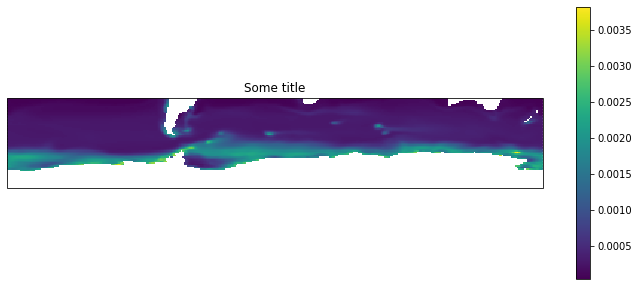

In [10]:
fig = plt.figure(figsize=(12,5)) # figsize= dimensions (width,height) en inches de ma figure

# Pour la ligne suivante, on a besoin de définir une projection avec CARTOPY et la fonction cartopy.crs
# ou ccrs dans ce code
# CRS = COORDINATE REFERENCE SYSTEM

ax = plt.axes(projection=ccrs.PlateCarree())

# Ensuite on utilise la fonction clé pour tracer une matrice: ax.pcolormesh
im=ax.pcolormesh(X,Y,chl[0,:,:],transform=ccrs.PlateCarree())

# on ajoute une colorbar que l'on garde très simple pour le moment

fig.colorbar(im)

ax.set_title("Some title")

# Et on affiche
plt.show()

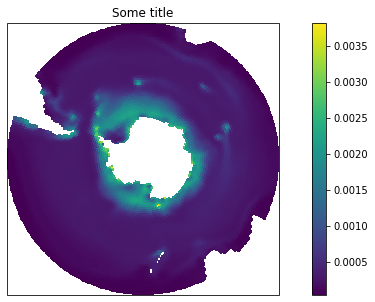

In [11]:
fig = plt.figure(figsize=(12,5))
# On change de projection: maintenant on veut quelque chose en circumpolaire (perspective= pôle Sud)
ax = plt.axes(projection=ccrs.SouthPolarStereo())

im=ax.pcolormesh(X,Y,chl[0,:,:],transform=ccrs.PlateCarree()) # transform reste en PlateCarree: défaut de cohérence de cartopy
fig.colorbar(im)
ax.set_title("Some title")

plt.show()

#### Quelques améliorations:

Dans Python, on peut adapter de très nombreux paramètres du plot.

Ci-dessous, on va adapter:

- la **colormap** (choix d'une palette de couleurs adaptée à la variable que l'on trace) et la **colorbar** (choix des valeurs min, max, choix de la légende);
- les **légendes sur les axes**;

- des paramètres classiques sur une carte comme: les **continents**, le **trait de côte**.

- on peut aussi rajouter d'autres éléments sur la carte: par exemple, la bathymétrie, les contours des Zones Economiques Exclusives (il faut pour cela charger d'autres fichiers).

##### Adapter les colormap et colorbar
Pour la colormap: on recommande très fortement d'utiliser des palettes de couleur adaptées aux daltonien·nes (pas de mélange rouge/vert) et de garder une échelle de couleurs ou l'oeil perçoit une gradation uniforme (pas de rainbow colormaps par exemple).
> argument cmap dans ax.pcolormesh: pour la bio j'utilise souvent cmocean.cm.algae ou cmocean.cm.matter
https://matplotlib.org/cmocean/

On peut changer l'échelle sur laquelle on trace les valeurs (par exemple, choisir une échelle log, ce qui est souvent approprié pour tracer des concentrations, comme ici la chlorophylle).
> argument norm et vmin, vmax dans ax.pcolormesh

On peut fixer le titre et les labels de la colorbar.
> arguments en plus dans la définition de la colorbar: cbar.set_label et cbar.ax.set_yticklabels respectivement.

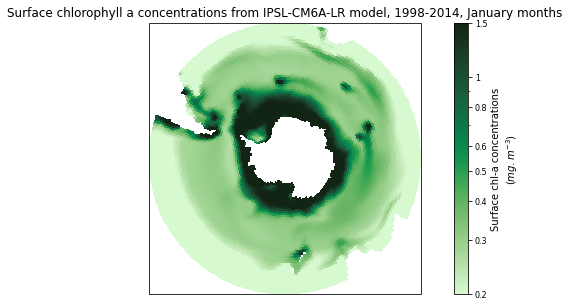

In [12]:
fig = plt.figure(figsize=(12,5))

ax = plt.axes(projection=ccrs.SouthPolarStereo())

im=ax.pcolormesh(X,Y,1e3*chl[0,:,:],cmap=cmocean.cm.algae,norm=matplotlib.colors.LogNorm(vmin=2e-1,vmax=1.5),transform=ccrs.PlateCarree())

cbar=fig.colorbar(im,orientation='vertical',ticks=[2e-1,3e-1,4e-1, 5e-1,6e-1,8e-1,1,1.5])
cbar.ax.set_yticklabels(['0.2','0.3','0.4', '0.5','0.6','0.8','1','1.5'],fontsize=8)
cbar.set_label('Surface chl-a concentrations\n$(mg.m^{-3})$',fontsize=10)

ax.set_title("Surface chlorophyll a concentrations from IPSL-CM6A-LR model, 1998-2014, January months")

plt.show()

NB pour Marion: les concentrations de chlorophylle IPSL ont un problème d'unités dans mes fichiers (en fait elles sont en g/m3 et pas en kg/m3) donc j'ai besoin de convertir en rajoutant le facteur *1e3* dans la ligne ax.pcolormesh.

### Gérer les labels sur les axes et rajouter les continents

> ax.coastlines: ajoute le trait de côte

> ax.add_feature(cfeature.LAND...) ajoute les continents

> ax.gridlines ajoute la grille (et donc les longitudes et latitudes).

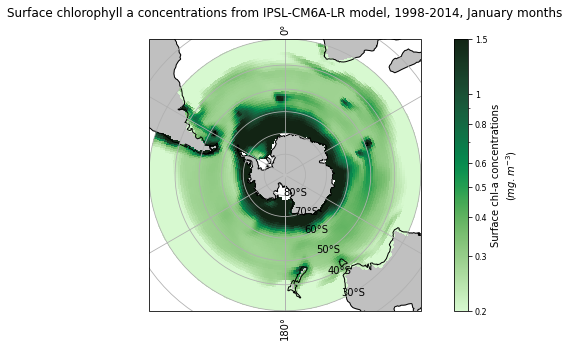

In [13]:
fig = plt.figure(figsize=(12,5))

ax = plt.axes(projection=ccrs.SouthPolarStereo())

ax.coastlines(resolution='110m')

ax.add_feature(cfeature.LAND, color='silver', zorder=1)
ax.gridlines(draw_labels=True)

im=ax.pcolormesh(X,Y,1e3*chl[0,:,:],cmap=cmocean.cm.algae,norm=matplotlib.colors.LogNorm(vmin=2e-1,vmax=1.5),transform=ccrs.PlateCarree())

cbar=fig.colorbar(im,orientation='vertical',ticks=[2e-1,3e-1,4e-1, 5e-1,6e-1,8e-1,1,1.5])
cbar.ax.set_yticklabels(['0.2','0.3','0.4', '0.5','0.6','0.8','1','1.5'],fontsize=8)
cbar.set_label('Surface chl-a concentrations\n$(mg.m^{-3})$',fontsize=10)

ax.set_title("Surface chlorophyll a concentrations from IPSL-CM6A-LR model, 1998-2014, January months")

plt.show()

### Ci-dessous, une manière plus avancée de rajouter des labels sur les axes (X,Y) et de modifier la colorbar:

Sauter cette partie dans un premier temps: elle montre des manières supplémentaires de customiser ses cartes.

**Gridlines**:
On définit un objet gl qui correspond aux gridlines: gl=ax.gridlines()
Et ensuite on modifie certains de ses paramètres: quelle épaisseur de ligne (linewidth=0.7), quelles valeurs de lon, lat tracer (fonctions gl.xlocator et gl.ylocator), quelle taille de police (gl.ylabel_style, gl.xlabel_style) etc.

**Colorbar**:
Pour changer sa localisation de manière simple, il faut lui définit un axe (ci-dessous cbar_ax=fig.add_axes([x,y,dx,dy]). Sur le plot, (0,0) indique le coin en bas à gauche. En fixant x=0.9 on a une colorbar à droite de l'image, en fixant y=0.15, elle commence à 15% de l'image en partant du bas. dx, dy gèrent sa longueur et son épaisseur.

On va faire un exemple en traçant spécifiquement la chlorophylle sur la zone de Kerguelen.

**fig.subplots_adjust**:
Pratique pour gérer les espaces sur une figure: par exemple, ici on ne veut pas que la colorbar se superpose à la figure. Voir les codes tuto_subplots pour plus d'applications de cette fonction.

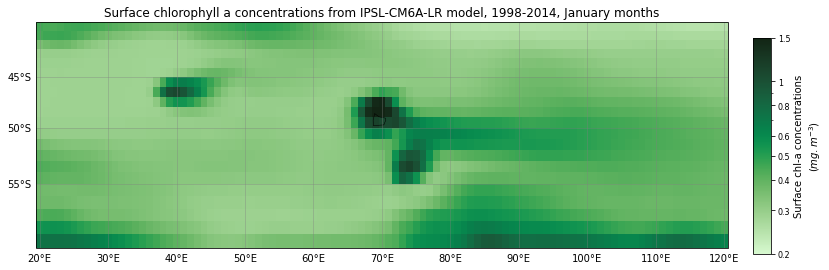

In [28]:
fig = plt.figure(figsize=(12,6))

X_Ker,Y_Ker=np.meshgrid(lon_ker,lat_ker)
# il y a besoin d'adapter X,Y à la région que l'on sélectionne: si on ne le fait pas, le code renvoie un message
#d'erreur en disant que les dimensions sont incompatibles

ax1 = plt.axes(projection=ccrs.Mercator())

ax1.coastlines(resolution='110m',linewidth=0.5)

ax1.add_feature(cfeature.LAND, color='silver', zorder=1)

gl = ax1.gridlines(crs=ccrs.PlateCarree(),
                  linewidth=0.7, color='gray', alpha=0.5)
 
gl.xlocator = mticker.FixedLocator([20,30,40,50,60,70,80,90,100,110,120]) # on veut légender les longitudes tous les 10°
gl.ylocator = mticker.FixedLocator([-55,-50,-45]) # on veut légender les latitudes tous les 5°

gl.bottom_labels=True # ça c'est pour dire qu'on veut légender les longitudes en bas de la carte et les latitudes à gauche
gl.left_labels=True
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.ylabel_style = {'size': 10, 'color': 'black'}
gl.xlabel_style = {'size':10,'color': 'black'}


im=ax1.pcolormesh(X_Ker,Y_Ker,1e3*chl_Ker[0,:,:],cmap=cmocean.cm.algae,norm=matplotlib.colors.LogNorm(vmin=2e-1,vmax=1.5),transform=ccrs.PlateCarree())


cbar_ax=fig.add_axes([0.9,0.25,0.02,0.5])
cbar=fig.colorbar(im,cax=cbar_ax,orientation='vertical',ticks=[2e-1,3e-1,4e-1, 5e-1,6e-1,8e-1,1,1.5])
cbar.ax.set_yticklabels(['0.2','0.3','0.4', '0.5','0.6','0.8','1','1.5'],fontsize=8)
cbar.set_label('Surface chl-a concentrations\n$(mg.m^{-3})$',fontsize=10)

ax1.set_title("Surface chlorophyll a concentrations from IPSL-CM6A-LR model, 1998-2014, January months",fontsize=12)

fig.subplots_adjust(bottom=0.15, top=0.9, left=0.07, right=0.87)